# FDA 의료기기 Recall 기반 QA 의사결정 지원 시스템
### EDA → 모델링 → 오류 분석 → Confidence → 유사 Recall 검색 → 대시보드 통합

**팀 현지인** (유현지, 한인지, 황수현) · 작성 2026-10

---
## 0. 프로젝트 개요

| 항목 | 내용 |
|---|---|
| 문제 | 신규 품질이슈가 생기면 QA 담당자가 과거 유사 리콜과 원인을 직접 검색해 비교한다. 리콜 사유는 수만 건의 비정형 영어 텍스트라 사람이 일일이 비교하기 어렵다. |
| 목표 | 입력한 Recall Reason에 대해 **Root Cause 후보(Top-3) + Confidence + 과거 유사 Recall**을 제시하고, **최종 판단은 Human QA**가 하도록 돕는 의사결정 지원 도구 |
| 데이터 | openFDA Medical Device Recall (1997~2026.7), 제품 행 58,999개 → **Recall Event 22,468건** (확정 Root Cause 16,025건) |
| 분류체계 | 프로젝트 정의 7-class: 설계 / 소프트웨어 / 공정·변경관리 / 자재·부품 / 포장·라벨링 / 인적요인 / 규제·인허가 (+ 미확정) |
| 최종 구성 | Word+Character TF-IDF + SGD → Top-3 · Confidence(Top-1 확률) → MiniLM 유사 Recall 검색 → Streamlit 대시보드(Human QA 판단 기록) |

### 이 노트북의 구성과 표기 규칙
1. 데이터 구조 → 2. EDA(질문 → 분석 → 발견 → 설계 결정) → 3. 모델링 → 4. 오류 분석 → 5. Confidence → 6. 유사 Recall 검색 → 7. 대시보드 통합 → 8. 결론

* **[재계산]**: 이 노트북이 저장소의 데이터·아티팩트로 직접 계산한 결과입니다.
* **[보고값]**: 프로젝트 보고서/노션에 기록된 값으로, 원본 실험 환경(과거 스냅샷, GPU 모델, 수동 평가 등)이 이 저장소에 없어 **다시 계산하지 않고 그대로 옮긴** 값입니다.
* 숫자 기준은 **final-v3**(Train 13,645 / Validation 1,338 / Test 1,042)이며, 과거 스냅샷(Snapshot A, Test 1,050건) 값은 반드시 따로 표기합니다.

> **실행 방법**: 저장소 루트(또는 `notebooks/`)에서 실행합니다. 프로젝트 루트는 `ARTIFACT_MANIFEST.csv` 위치로 자동 탐지합니다.
> `pip install -r requirements-notebook.txt` (유사 Recall 전체 파이프라인 셀(7.3)은 `sentence-transformers` 설치 + MiniLM 모델 다운로드가 가능한 환경에서만 동작하고, 아니면 건너뜁니다.)

## 1. 환경 설정과 데이터 로딩

In [1]:
import warnings, json, sys, os, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from scipy.stats import chi2_contingency, binomtest
warnings.filterwarnings("ignore")

def find_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "ARTIFACT_MANIFEST.csv").exists():
            return p
    raise FileNotFoundError("프로젝트 루트(ARTIFACT_MANIFEST.csv)를 찾을 수 없습니다. 저장소 루트 또는 notebooks/ 에서 실행하세요.")

ROOT = find_root()
sys.path.insert(0, str(ROOT))

# 한글 폰트: 환경에 있는 첫 번째 폰트를 사용 (Colab은 먼저 `!apt-get -qq install fonts-nanum` 후 런타임 재시작)
for f in (Path.home() / ".fonts").glob("*"):
    if f.suffix.lower() in (".ttf", ".otf"):
        fm.fontManager.addfont(str(f))
for name in ["Pretendard", "NanumGothic", "Malgun Gothic", "AppleGothic", "Noto Sans CJK KR", "Noto Sans KR"]:
    if any(x.name == name for x in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = name
        break
plt.rcParams.update({"axes.unicode_minus": False, "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#C9D1DD", "axes.labelcolor": "#4B5565", "xtick.color": "#4B5565", "ytick.color": "#4B5565"})
BLUE, MID, PALE, DEEP, GRAY, LG = "#1566F3", "#7FAAF8", "#D6E4FD", "#0B3EA8", "#6B7684", "#C9D1DD"

CLASSES = ["설계", "소프트웨어", "공정/변경관리", "자재/부품", "포장/라벨링", "인적요인", "규제/인허가"]
print("프로젝트 루트:", ROOT)
print("Python", platform.python_version(), "| pandas", pd.__version__, "| numpy", np.__version__)

프로젝트 루트: /home/claude/work/repo/fda-recall-qa-decision-support
Python 3.12.3 | pandas 3.0.2 | numpy 2.4.4


In [2]:
ev = pd.read_csv(ROOT / "out/event_features_integrated_v3.csv", low_memory=False)
print("Event 수:", f"{len(ev):,}", "| 컬럼 수:", ev.shape[1])
ev[["res_event_number", "event_product_count", "root_cause_group", "reason_for_recall_clean", "specialties", "year"]].head(5)

Event 수: 22,468 | 컬럼 수: 32


,res_event_number,event_product_count,root_cause_group,reason_for_recall_clean,specialties,year
0,25002,1,미확정,Separation between lid and housing unit.,UNKNOWN,2002
1,25007,1,미확정,Inaccurate dimensions of the device. Offshore ...,Orthopedic,2002
2,25009,1,미확정,"Software anomaly, incorrect coding. Some comme...",Clinical Chemistry,2002
3,25010,1,미확정,"Software anomally - animal ranges, when desire...",Clinical Chemistry,2002
4,25016,1,미확정,Products are being distributed from importer d...,Ophthalmic,2002


### 주요 컬럼
| 컬럼 | 의미 | 역할 |
|---|---|---|
| `res_event_number` | Recall Event ID (제품 행 여러 개가 하나의 Event에 연결) | 분석 단위 |
| `reason_for_recall_clean` | 정제된 리콜 사유(영어) | **모델 입력**, 유사 검색 대상 |
| `root_cause_group` | 프로젝트 7-class + 미확정 | **정답(타깃)** |
| `specialties`, `device_classes`, `firm_norm` | 제품군, 기기 등급, 정규화한 기업명 | 화면의 참고 맥락 (분류 입력 아님) |
| `event_date_initiated_clean`, `year` | 리콜 개시일 | 시간 기준 분할, 검색 기준일 필터 |

## 2. EDA — 분석 질문 → 분석 → 발견 → 설계 결정
### Q1. 한 행이 한 사건인가? (분석 단위)

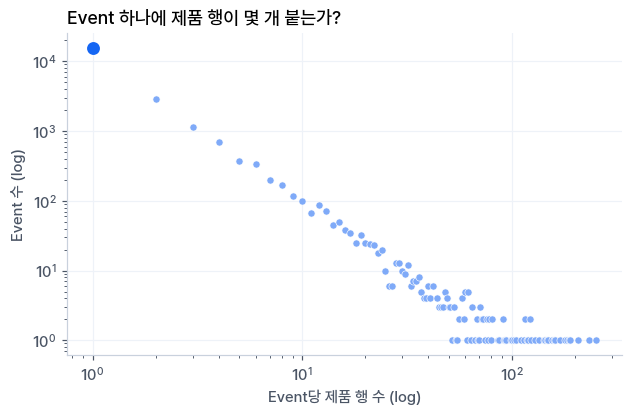

[재계산] 1행짜리 Event: 15,685건 (69.8%), 최대 254행


In [3]:
vc = ev.event_product_count.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.scatter(vc.index, vc.values, s=22, color=MID, edgecolor="white", lw=0.4, zorder=3)
ax.scatter([1], [vc.loc[1]], s=55, color=BLUE, zorder=4)
ax.set_xscale("log"); ax.set_yscale("log"); ax.grid(color="#EEF2F8")
ax.set_xlabel("Event당 제품 행 수 (log)"); ax.set_ylabel("Event 수 (log)")
ax.set_title("Event 하나에 제품 행이 몇 개 붙는가?", loc="left")
plt.show()
print(f"[재계산] 1행짜리 Event: {vc.loc[1]:,}건 ({vc.loc[1]/len(ev)*100:.1f}%), 최대 {ev.event_product_count.max()}행")

**발견**: 약 70%의 Event는 1행이지만 최대 254행이 붙는 긴 꼬리 분포입니다.
EDA 보고서에 따르면 Orthopedic 제품군의 1위 원인은 **제품 행 기준 설계 27.8%**, **Event 기준 공정/변경관리 26.4%**로 뒤집힙니다 **[보고값]**.
**결정**: 분석·모델·검색의 단위를 모두 **Event**로 통일했습니다.

### Q2. Root Cause 분포와 미확정 비율은?

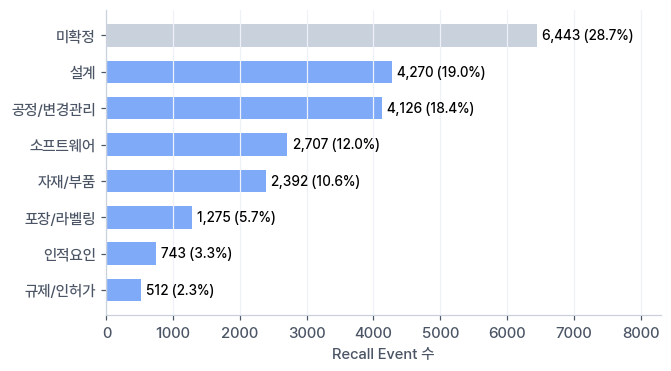

[재계산] 확정 Event: 16,025 | 미확정: 6,443


In [4]:
dist = ev.root_cause_group.value_counts()
order = list(dist.index)[::-1]
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.barh(order, [dist[k] for k in order], color=[LG if k == "미확정" else MID for k in order], height=0.62)
for i, k in enumerate(order):
    ax.text(dist[k] + 80, i, f"{dist[k]:,} ({dist[k]/len(ev)*100:.1f}%)", va="center", fontsize=9)
ax.set_xlim(0, 8300); ax.grid(axis="x", color="#EEF2F8"); ax.set_xlabel("Recall Event 수")
plt.show()
print("[재계산] 확정 Event:", f"{(ev.root_cause_group != '미확정').sum():,}", "| 미확정:", f"{(ev.root_cause_group == '미확정').sum():,}")

### Q3. 시간이 지나면서 데이터는 어떻게 달라지는가? → 왜 시간 기준 분할인가

[재계산] 시간 기준 분할 (확정 Event): {'Train': 13645, 'Validation': 1338, 'Test': 1042}
                   min         max
split                             
Test        2025-01-02  2026-07-30
Train       2000-04-11  2022-12-29
Validation  2023-01-03  2024-12-31


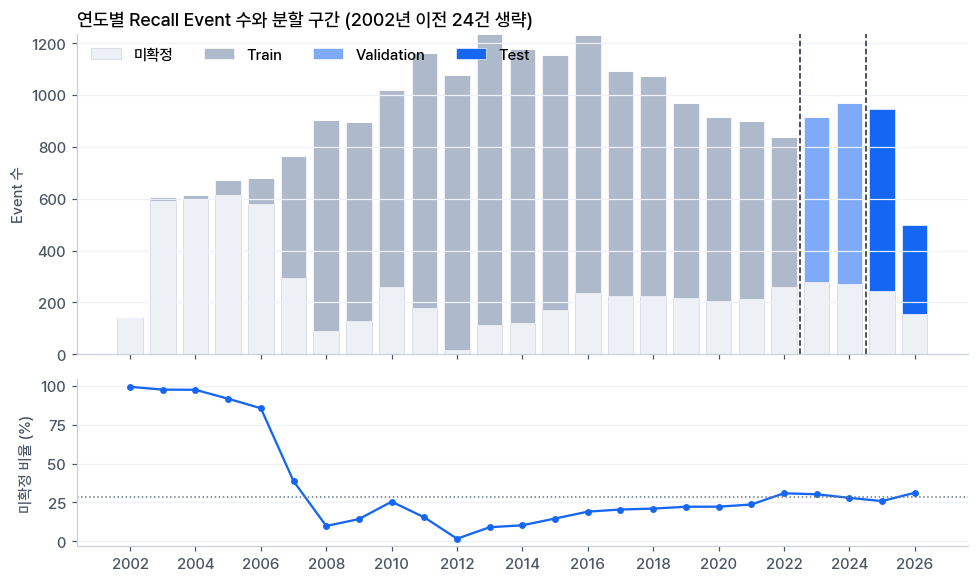

[재계산] 미확정 비율: 2006년 85.5% → 2008년 9.9% → 2022~2026년 25.8~31.2%


In [5]:
ev["yr"] = ev.year.astype(int)
conf = ev[ev.root_cause_group != "미확정"].copy()
def split_name(y):
    return "Train" if y <= 2022 else ("Validation" if y <= 2024 else "Test")
conf["split"] = conf.yr.map(split_name)
print("[재계산] 시간 기준 분할 (확정 Event):", conf.split.value_counts().to_dict())
assert conf.split.value_counts().to_dict() == {"Train": 13645, "Validation": 1338, "Test": 1042}, "프로젝트 분할 건수와 다릅니다"
print(conf.groupby("split").event_date_initiated_clean.agg(["min", "max"]))

ev["split"] = np.where(ev.root_cause_group == "미확정", "미확정", ev.yr.map(split_name))
ct = pd.crosstab(ev.yr, ev.split).reindex(columns=["Train", "Validation", "Test", "미확정"]).fillna(0).astype(int).loc[2002:2026]
unres = ct["미확정"] / ct.sum(axis=1) * 100

fig, (a, b) = plt.subplots(2, 1, figsize=(9, 5.4), sharex=True, gridspec_kw={"height_ratios": [2.3, 1.2]})
bottom = np.zeros(len(ct))
for k, c in [("미확정", "#EDF0F5"), ("Train", "#AEB9CB"), ("Validation", MID), ("Test", BLUE)]:
    a.bar(ct.index, ct[k], bottom=bottom, color=c, label=k, width=0.78, edgecolor="#C9D1DD" if k == "미확정" else "white", lw=0.4)
    bottom += ct[k].values
for x in (2022.5, 2024.5): a.axvline(x, color="#1B2430", ls="--", lw=1)
a.legend(ncol=4, frameon=False, loc="upper left"); a.set_ylabel("Event 수"); a.grid(axis="y", color="#EEF2F8")
a.set_title("연도별 Recall Event 수와 분할 구간 (2002년 이전 24건 생략)", loc="left")
b.plot(unres.index, unres.values, color=BLUE, marker="o", ms=3.5); b.axhline(28.68, color=GRAY, ls=":", lw=1)
b.set_ylabel("미확정 비율 (%)"); b.grid(axis="y", color="#EEF2F8"); b.set_xticks(range(2002, 2027, 2))
plt.tight_layout(); plt.show()
print(f"[재계산] 미확정 비율: 2006년 {unres.loc[2006]:.1f}% → 2008년 {unres.loc[2008]:.1f}% → 2022~2026년 {unres.loc[2022:2026].min():.1f}~{unres.loc[2022:2026].max():.1f}%")

**발견**: 미확정 비율이 2006년까지 85% 이상이었다가 2008년 이후 낮아지고 최근 다시 26~31%입니다. 즉 **미확정은 무작위가 아니라 시간에 쏠려 있습니다**.
**결정**: ① 분류 학습·평가에서는 미확정을 제외하고, ② 검색 대상에는 활용하며, ③ 모델 적용 범위를 "확정된 과거 사례 기반 후보 지원"으로 한정합니다.

### Q4. 무작위 분할은 점수를 부풀리는가? (데이터 누수)
이 노트북은 **Event 단위로 정확히 같은 리콜 사유 문장**이 Train에 이미 있는 Test 비율을 직접 계산합니다. 프로젝트 EDA 보고서의 값(Random 69.7% / Group 3.9% / Time 0.3%)은 **제품 행 단위**(같은 Event에 속한 제품 행의 사유 문장이 98% 동일) 측정값이며, 제품 행 데이터(`recall_processed_integrated_v3.csv`)는 이 저장소에 없어 **[보고값]**으로만 옮깁니다.

In [6]:
txt = conf.reason_for_recall_clean.str.lower().str.strip()
def exact_overlap(train_idx, test_idx):
    seen = set(txt.loc[train_idx])
    return txt.loc[test_idx].isin(seen).mean() * 100

n_tr, n_va, n_te = 13645, 1338, 1042
rng = np.random.RandomState(42)
perm = rng.permutation(conf.index.values)
rand_tr, rand_te = perm[:n_tr], perm[n_tr + n_va:n_tr + n_va + n_te]
time_tr, time_te = conf.index[conf.split == "Train"], conf.index[conf.split == "Test"]
res = pd.DataFrame({"분할 방식": ["Random (Event 단위, seed=42)", "Time (연도 기준)"],
                    "Test 중 같은 문장이 Train에 존재 (%)": [exact_overlap(rand_tr, rand_te), exact_overlap(time_tr, time_te)]}).round(2)
display(res)
print("[보고값] EDA 보고서(제품 행 기준): Random 69.7% / Group(Event) 3.9% / Time 0.3%")

,분할 방식,Test 중 같은 문장이 Train에 존재 (%)
0,"Random (Event 단위, seed=42)",1.25
1,Time (연도 기준),0.38


[보고값] EDA 보고서(제품 행 기준): Random 69.7% / Group(Event) 3.9% / Time 0.3%


**발견**: ① **Event 단위**로 보면 정확히 같은 문장이 Train에 있는 비율은 작지만(위 재계산: Random 1.25% → Time 0.38%, 시간 분할이 약 3분의 1) 시간 분할이 더 낮습니다. ② 큰 누수는 **제품 행 단위**에서 생깁니다. 같은 Event의 제품 행들이 같은 문장을 공유하므로, 행 단위로 무작위 분할하면 시험 문장의 69.7%가 학습에 그대로 들어갑니다 **[보고값]**.
**결정**: (1) 분석 단위를 **Event**로 통일하고, (2) 서비스 상황(과거로 학습해 미래를 판단)과 같은 **시간 기준 분할**(Train ≤2022 / Valid 2023~2024 / Test ≥2025)을 채택하며, (3) 유사 검색도 **검색 기준일 이전 사례만** 사용합니다.

### Q5. 제품군에 따라 Root Cause 구성이 다른가?

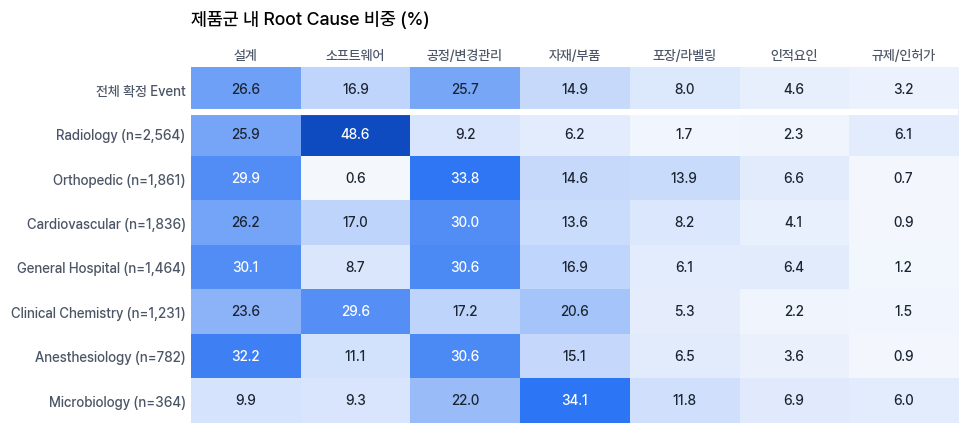

[재계산] χ² 검정 (확정 Event 16,025건): χ²=4,296.3, p=0.00e+00, Cramér's V = 0.211


In [7]:
conf["spec"] = conf.specialties.astype(str).str.split("|").str[0].str.split(";").str[0].str.strip()
rows = ["Radiology", "Orthopedic", "Cardiovascular", "General Hospital", "Clinical Chemistry", "Anesthesiology", "Microbiology"]
tab = pd.crosstab(conf.spec, conf.root_cause_group)
pct = tab.div(tab.sum(1), axis=0) * 100
chi, p, dof, _ = chi2_contingency(tab)
V = np.sqrt(chi / (tab.values.sum() * (min(tab.shape) - 1)))
allp = conf.root_cause_group.value_counts(normalize=True) * 100
mat = np.vstack([allp[CLASSES].values] + [pct.loc[r, CLASSES].values for r in rows])
labels = ["전체 확정 Event"] + rows

from matplotlib.colors import LinearSegmentedColormap
cm = LinearSegmentedColormap.from_list("b", ["#F6F9FE", "#BBD2FB", "#1566F3", "#0B3EA8"])
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.imshow(mat, cmap=cm, vmin=0, vmax=55, aspect="auto")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i, j]:.1f}", ha="center", va="center", fontsize=9, color="white" if mat[i, j] >= 28 else "#1B2430")
ax.set_xticks(range(7)); ax.set_xticklabels(CLASSES, fontsize=9); ax.xaxis.tick_top()
ax.set_yticks(range(len(labels))); ax.set_yticklabels([f"{l} (n={int(tab.loc[l].sum()):,})" if l in tab.index else l for l in labels], fontsize=9)
ax.axhline(0.5, color="white", lw=4); ax.tick_params(length=0)
for s in ax.spines.values(): s.set_visible(False)
plt.title("제품군 내 Root Cause 비중 (%)", loc="left", pad=28); plt.show()
print(f"[재계산] χ² 검정 (확정 Event {int(tab.values.sum()):,}건): χ²={chi:,.1f}, p={p:.2e}, Cramér's V = {V:.3f}")

**발견**: Radiology는 소프트웨어(48.6%), Orthopedic은 공정/변경관리(33.8%)·설계(29.9%), Microbiology는 자재/부품(34.1%) 비중이 높습니다. Cramér's V = 0.211로 연관은 작지만 유의합니다.
**해석 주의**: "제품군이 원인을 결정한다"가 아니라 **"제품군별 구성비에 차이가 확인되었다"**입니다.
**결정**: 제품군은 모델 입력이 아니라 **화면의 참고 맥락**(Specialty·Product Code)으로 사용합니다.

### Q6. Recall Reason은 어떤 텍스트인가?

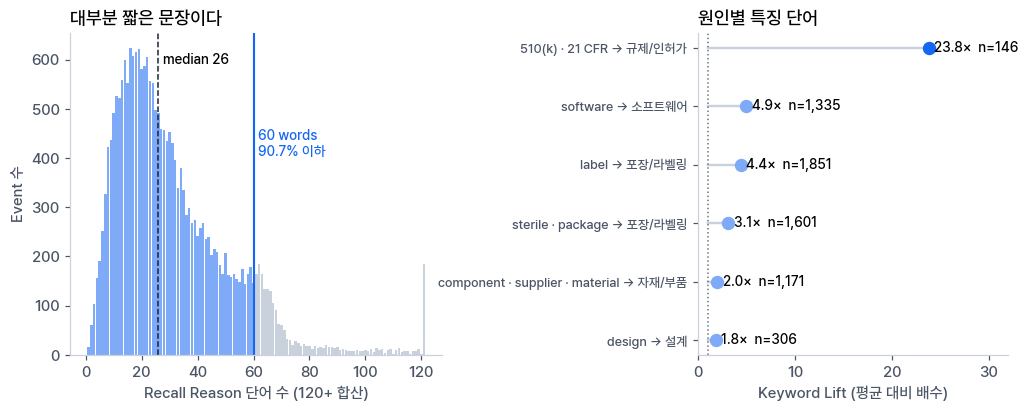

[재계산] 단어 수 중앙값 26, 90.7%가 60단어 이하


In [8]:
wc = ev.reason_for_recall_clean.fillna("").str.split().str.len()
med, le60 = wc.median(), (wc <= 60).mean() * 100
h = wc.clip(upper=121).value_counts().sort_index()

txt_l = conf.reason_for_recall_clean.str.lower().fillna("")
base = conf.root_cause_group.value_counts(normalize=True)
kw = [("510(k) · 21 CFR", r"510\(k\)|21 cfr", "규제/인허가"), ("software", r"software", "소프트웨어"), ("label", r"label", "포장/라벨링"),
      ("sterile · package", r"sterile|packag", "포장/라벨링"), ("component · supplier · material", r"component|supplier|material", "자재/부품"), ("design", r"design", "설계")]
lift = []
for name, pat, cls in kw:
    m = txt_l.str.contains(pat, regex=True)
    lift.append((name, cls, conf[m].root_cause_group.eq(cls).mean() / base[cls], int(m.sum())))

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.2, 1], "wspace": 0.75})
a.bar(h.index, h.values, width=0.9, color=[MID if i <= 60 else LG for i in h.index])
a.axvline(med, color="#1B2430", ls="--", lw=1); a.axvline(60, color=BLUE, lw=1.4)
a.text(med + 1.5, h.max() * 0.95, f"median {med:.0f}", fontsize=9); a.text(61.5, h.max() * 0.65, f"60 words\n{le60:.1f}% 이하", fontsize=9, color=BLUE)
a.set_xlabel("Recall Reason 단어 수 (120+ 합산)"); a.set_ylabel("Event 수"); a.set_title("대부분 짧은 문장이다", loc="left")
ys = np.arange(len(lift))[::-1]
for y, (n_, c_, l_, k_) in zip(ys, lift):
    b.plot([1, l_], [y, y], color=LG, lw=1.6); b.scatter([l_], [y], s=60, color=BLUE if l_ > 10 else MID, zorder=3); b.text(l_ + 0.6, y, f"{l_:.1f}×  n={k_:,}", va="center", fontsize=9)
b.axvline(1, color=GRAY, ls=":", lw=1); b.set_yticks(ys); b.set_yticklabels([f"{n_} → {c_}" for n_, c_, _, _ in lift], fontsize=8.5)
b.set_xlim(0, 32); b.set_xlabel("Keyword Lift (평균 대비 배수)"); b.set_title("원인별 특징 단어", loc="left")
plt.show()
print(f"[재계산] 단어 수 중앙값 {med:.0f}, {le60:.1f}%가 60단어 이하")

**발견**: 중앙값 26단어의 짧은 문장이며, 예를 들어 "510(k)/21 CFR"가 들어가면 규제/인허가일 가능성이 평균의 약 24배입니다.
**결정**: 키워드 단서가 뚜렷하므로 **TF-IDF 기반 선형 모델**을 중심에 두고, 같은 키워드를 화면의 "모델 예측 근거(XAI)"로 보여줍니다.

### Q7. 미확정은 무작위인가? (선택 편향)

In [9]:
def cramers_v(table):
    chi2 = chi2_contingency(table)[0]
    return np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))
ev["is_unres"] = (ev.root_cause_group == "미확정")
ev["spec1"] = ev.specialties.astype(str).str.split("|").str[0].str.split(";").str[0].str.strip()
v_year = cramers_v(pd.crosstab(ev.yr[ev.yr >= 2002], ev.is_unres[ev.yr >= 2002]))
v_spec = cramers_v(pd.crosstab(ev.spec1, ev.is_unres))
print(f"[재계산] 미확정 여부 × 연도 Cramér's V = {v_year:.4f} / 미확정 여부 × 제품군 V = {v_spec:.4f}")
print("[보고값] EDA 보고서: 연도 V 0.5616 / 제품군 V 0.2075 (집계 범위가 조금 다를 수 있음)")

[재계산] 미확정 여부 × 연도 Cramér's V = 0.5604 / 미확정 여부 × 제품군 V = 0.1781
[보고값] EDA 보고서: 연도 V 0.5616 / 제품군 V 0.2075 (집계 범위가 조금 다를 수 있음)


**발견**: 미확정 여부는 제품군보다 **연도**와 훨씬 강하게 연관되어 있습니다.
**결정**: 모델을 "FDA 전체 Recall 예측"이 아니라 **"확정된 과거 사례로 신규 Recall의 후보를 지원하는 모델"**로 정의합니다.

### EDA → 시스템 설계 결정 요약
| 분석 질문 | 발견 | 시스템 설계에 준 영향 |
|---|---|---|
| 제품 행으로 세면 결론이 같은가? | Orthopedic 1위 원인이 바뀜 **[보고값]** | 분석·모델·검색 단위를 Event로 통일 |
| 분할 방식에 따라 누수가 다른가? | 제품 행 단위 Random 69.7% vs Time 0.3% **[보고값]**, Event 단위 재계산 1.25% vs 0.38% | Event 단위 + 시간 기준 분할, 검색은 기준일 이전 사례만 |
| 미확정은 무작위인가? | 연도에 쏠림 | 분류 제외, 검색 활용, 적용 범위 한정 |
| 제품군에 따라 Root Cause가 다른가? | V=0.211, 구성비 차이 | 화면의 참고 맥락 |
| 특정 기업이 패턴을 만드는가? | 상위 3개 기업을 빼도 변화 3.4%p 이내 **[보고값]** | 제품군 차이를 기업 효과로 해석하지 않음 |
| 같은 기기유형이 반복되는가? | 약 32% 재등장 **[보고값]** | 유사 Recall 검색의 근거 |
| Recall Reason은 어떤 텍스트인가? | 짧고 특징 키워드가 있음 | TF-IDF 선형 모델, 예측 근거 키워드 |

## 3. 모델링
### 3.1 평가 설계와 채택 기준
* 입력: `reason_for_recall_clean`(소문자화) → 정답: 7-class Root Cause (미확정 제외)
* 클래스 불균형(인적요인 약 3%)이므로 **Macro F1**을 주지표로, 후보 3개를 주는 구조라 **Top-k Hit Rate**를 함께 봅니다.
* 모델 선택·임계값 결정은 Validation에서, **Test는 마지막 확인용**입니다.
* **채택 기준**: 기준선보다 숫자가 높아도 **McNemar 검정 또는 Bootstrap 95% CI로 확인된 경우에만 "개선"**으로 인정합니다.

### 3.2 [보고값] 14개 모델 비교 (과거 스냅샷, Test 1,050건)
원본 실험에는 GPU 기반 DistilBERT, Sentence-BERT, 트리 모델이 포함되어 있어 이 저장소에서 다시 실행하지 않았습니다. 아래는 **모델 비교 결과보고서의 값**입니다.

In [10]:
reported14 = pd.DataFrame([
    ("TF-IDF + SGD (log_loss)", 0.442, 0.507, "기준선보다 유의하게 높음 (McNemar p=0.025)"),
    ("DistilBERT 파인튜닝", 0.441, 0.465, "기준선과 차이 유의하지 않음 (p=0.124)"),
    ("TF-IDF + LogReg (공식 기준선)", 0.437, 0.489, "기준"),
    ("TF-IDF + ComplementNB", 0.437, 0.519, "동일 수준"),
    ("TF-IDF+정형 + LogReg", 0.432, 0.483, "낮음"),
    ("TF-IDF + LinearSVC", 0.418, None, ""), ("TF-IDF + kNN(cosine)", 0.418, None, ""), ("TF-IDF+정형 + LightGBM", 0.412, None, ""),
    ("TF-IDF+정형 + XGBoost", 0.408, None, ""), ("SVD+정형 + MLP", 0.398, None, ""), ("SVD+정형 + RandomForest", 0.394, None, ""),
    ("SBERT(MiniLM) + LogReg", 0.387, None, ""), ("TF-IDF + MultinomialNB", 0.308, None, ""), ("Dummy (최빈값)", 0.055, None, ""),
], columns=["모델", "Test Macro F1", "Accuracy", "기준선(0.437) 대비"])
display(reported14.fillna("-"))

,모델,Test Macro F1,Accuracy,기준선(0.437) 대비
0,TF-IDF + SGD (log_loss),0.442,0.507,기준선보다 유의하게 높음 (McNemar p=0.025)
1,DistilBERT 파인튜닝,0.441,0.465,기준선과 차이 유의하지 않음 (p=0.124)
2,TF-IDF + LogReg (공식 기준선),0.437,0.489,기준
3,TF-IDF + ComplementNB,0.437,0.519,동일 수준
4,TF-IDF+정형 + LogReg,0.432,0.483,낮음
5,TF-IDF + LinearSVC,0.418,-,
6,TF-IDF + kNN(cosine),0.418,-,
7,TF-IDF+정형 + LightGBM,0.412,-,
8,TF-IDF+정형 + XGBoost,0.408,-,
9,SVD+정형 + MLP,0.398,-,


추가 실험(v2, **[보고값]**): 튜닝은 SGD에서 변화가 없었고(LogReg는 C=3에서 0.430으로 하락), 새 모델(LogisticOVR 0.433, kNN 0.421, XGBoost 재튜닝 0.426, LightGBM 0.398, CatBoost 0.391, BernoulliNB 0.368, ExtraTrees 0.335)은 모두 기준선(0.437)을 넘지 못했습니다. Voting(SGD+LogReg)은 0.453이지만 SGD 단독 대비 **p=0.210**으로 개선으로 확정할 수 없었습니다.
→ 이 데이터·피처 조합의 실질적 상한은 Macro F1 약 **0.44~0.45**로 판단했습니다.

### 3.3 [재계산] final-v3 기준 재현 실험
저장소의 데이터와 프로젝트 설정(`modeling/03_word_char_tfidf/artifacts/experiment_config.json`)으로 **직접 학습**합니다.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from scipy.sparse import hstack

cfg = json.loads((ROOT / "modeling/03_word_char_tfidf/artifacts/experiment_config.json").read_text(encoding="utf-8"))
conf["reason_lower"] = conf.reason_for_recall_clean.str.lower()
tr, va, te = (conf[conf.split == s] for s in ("Train", "Validation", "Test"))
print({k: len(v) for k, v in (("Train", tr), ("Validation", va), ("Test", te))})

wv = TfidfVectorizer(ngram_range=tuple(cfg["word_tfidf_settings"]["ngram_range"]), min_df=cfg["word_tfidf_settings"]["min_df"],
                     max_features=cfg["word_tfidf_settings"]["max_features"], sublinear_tf=True)
cv = TfidfVectorizer(analyzer="char_wb", ngram_range=tuple(cfg["best_character_tfidf_settings"]["ngram_range"]),
                     min_df=cfg["best_character_tfidf_settings"]["min_df"], sublinear_tf=True)
Xw_tr, Xw_va, Xw_te = wv.fit_transform(tr.reason_lower), wv.transform(va.reason_lower), wv.transform(te.reason_lower)
Xc_tr, Xc_va, Xc_te = cv.fit_transform(tr.reason_lower), cv.transform(va.reason_lower), cv.transform(te.reason_lower)
cw = cfg["best_char_weight"]
X = {"word": (Xw_tr, Xw_va, Xw_te), "char": (Xc_tr, Xc_va, Xc_te),
     "word+char": tuple(hstack([w, c * cw], format="csr") for w, c in zip((Xw_tr, Xw_va, Xw_te), (Xc_tr, Xc_va, Xc_te)))}
print({k: v[0].shape[1] for k, v in X.items()}, "특징 수")

{'Train': 13645, 'Validation': 1338, 'Test': 1042}


{'word': 29184, 'char': 109726, 'word+char': 138910} 특징 수


In [12]:
sgd_cfg = cfg["sgd_settings"]
def make_sgd():
    return SGDClassifier(loss=sgd_cfg["loss"], class_weight=sgd_cfg["class_weight"], alpha=sgd_cfg["alpha"],
                         max_iter=sgd_cfg["max_iter"], random_state=sgd_cfg["random_state"])
y_tr, y_va, y_te = tr.root_cause_group.values, va.root_cause_group.values, te.root_cause_group.values

models = {}
for name in ("word", "char", "word+char"):
    m = make_sgd().fit(X[name][0], y_tr); models["SGD · " + name] = (m, X[name])
base_lr = LogisticRegression(class_weight="balanced", max_iter=2000).fit(Xw_tr, y_tr); models["LogReg · word (기준선 후보)"] = (base_lr, X["word"])
models["ComplementNB · word"] = (ComplementNB().fit(Xw_tr, y_tr), X["word"])
models["LinearSVC · word+char"] = (LinearSVC(class_weight="balanced", random_state=42).fit(X["word+char"][0], y_tr), X["word+char"])

rows_ = []
for name, (m, xs) in models.items():
    pred = m.predict(xs[2]); r = {"모델": name, "Accuracy": accuracy_score(y_te, pred), "Macro F1": f1_score(y_te, pred, average="macro"),
                                   "Weighted F1": f1_score(y_te, pred, average="weighted")}
    if hasattr(m, "predict_proba"):
        P = m.predict_proba(xs[2]); cls = list(m.classes_); rank = np.argsort(-P, axis=1)
        for k in (2, 3): r[f"Top-{k}"] = np.mean([y_te[i] in [cls[j] for j in rank[i, :k]] for i in range(len(y_te))])
    rows_.append(r)
res_df = pd.DataFrame(rows_).set_index("모델").round(4)
reported = {"SGD · word": 0.4424, "SGD · char": 0.4465, "SGD · word+char": 0.4496, "LogReg · word (기준선 후보)": 0.4373}
res_df["프로젝트 보고 Macro F1"] = pd.Series(reported)
display(res_df)
print("final-v3 Test n =", len(y_te))

,Accuracy,Macro F1,Weighted F1,Top-2,Top-3,프로젝트 보고 Macro F1
모델,,,,,,
SGD · word,0.5067,0.4424,0.5038,0.7620,0.8916,0.4424
SGD · char,0.4962,0.4465,0.4915,0.7543,0.8868,0.4465
SGD · word+char,0.5048,0.4496,0.5026,0.7697,0.8992,0.4496
LogReg · word (기준선 후보),0.4885,0.4373,0.4907,0.7409,0.8848,0.4373
ComplementNB · word,0.5182,0.4361,0.5031,0.7735,0.8810,NaN
LinearSVC · word+char,0.4866,0.4278,0.4934,NaN,NaN,NaN


final-v3 Test n = 1042


**해석**: `Word`·`Char`·`Word+Char`·`LogReg` 기준선의 재계산 Macro F1은 프로젝트 보고값(0.4424 / 0.4465 / 0.4496 / 0.4373)과 소수 넷째 자리까지 일치했습니다(두 열을 함께 표시하므로 실행 환경이 다르면 직접 확인할 수 있습니다). ComplementNB·LinearSVC는 보고서와 스냅샷·피처 설정이 달라 값이 다릅니다. 모델 간 차이는 작아서 **통계적으로** 검정해야 합니다.

### 3.4 통계 검정: Word+Char가 Word보다 좋은가? (McNemar + Bootstrap)

McNemar (정답 총량): Word만 맞힘 46건 / Word+Char만 맞힘 44건 → 정확 검정 p = 0.916


Bootstrap 2,000회: Macro F1 차이(Word+Char − Word) = +0.0072, 95% CI [-0.0107, +0.0274]
[보고값] 프로젝트 기록: CI [-0.0107, +0.0290], McNemar p = 0.916  (McNemar는 일치, Bootstrap은 난수에 따라 상한이 근소하게 다름)


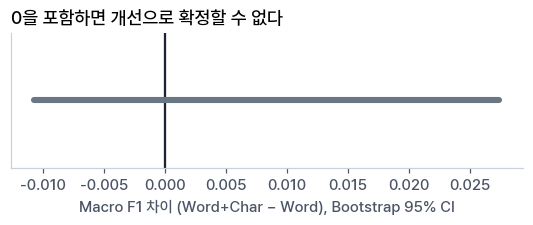

In [13]:
m_w, m_wc = models["SGD · word"][0], models["SGD · word+char"][0]
pw, pwc = m_w.predict(X["word"][2]), m_wc.predict(X["word+char"][2])
cw_, cwc_ = (pw == y_te), (pwc == y_te)
b = int((cw_ & ~cwc_).sum()); c_ = int((~cw_ & cwc_).sum())
p_mc = binomtest(min(b, c_), b + c_, 0.5).pvalue
print(f"McNemar (정답 총량): Word만 맞힘 {b}건 / Word+Char만 맞힘 {c_}건 → 정확 검정 p = {p_mc:.3f}")

rng = np.random.RandomState(42); n = len(y_te); diffs = []
for _ in range(2000):
    i = rng.randint(0, n, n)
    diffs.append(f1_score(y_te[i], pwc[i], average="macro") - f1_score(y_te[i], pw[i], average="macro"))
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f"Bootstrap 2,000회: Macro F1 차이(Word+Char − Word) = {f1_score(y_te, pwc, average='macro') - f1_score(y_te, pw, average='macro'):+.4f}, 95% CI [{lo:+.4f}, {hi:+.4f}]")
print("[보고값] 프로젝트 기록: CI [-0.0107, +0.0290], McNemar p = 0.916  (McNemar는 일치, Bootstrap은 난수에 따라 상한이 근소하게 다름)")
fig, ax = plt.subplots(figsize=(6, 1.6)); ax.axvline(0, color="#1B2430"); ax.plot([lo, hi], [0, 0], color=GRAY, lw=4, solid_capstyle="round")
ax.set_yticks([]); ax.set_xlabel("Macro F1 차이 (Word+Char − Word), Bootstrap 95% CI"); ax.set_title("0을 포함하면 개선으로 확정할 수 없다", loc="left"); plt.show()

**결론**: 신뢰구간이 0을 포함하고 McNemar도 유의하지 않으면 **"Word+Char가 더 좋다"고 말할 수 없습니다**.
그럼에도 Word+Char를 대시보드의 기준 모델로 연결한 이유는 (1) final-v3 기준으로 저장된 모델이 있어 **재현 가능**하고 (2) 지표가 가장 높으며 (3) 선형 모델이라 **키워드 근거를 제공**할 수 있기 때문입니다. (설정 파일의 모델 역할도 `CURRENT_EXECUTABLE_BASELINE`입니다.)

### 3.5 저장된 모델(대시보드가 실제 사용하는 모델) 검증
재학습 결과가 아니라 **저장된 아티팩트**로 예측해, 프로젝트가 저장한 예측 확률 파일과 일치하는지 확인합니다.

In [14]:
from classification.day16_classification_confidence_module import FinalV3ClassificationConfidence
rt = FinalV3ClassificationConfidence(ROOT)
pred_file = pd.read_csv(ROOT / "out/day15_final_v3_confidence_revalidation/confidence_predictions.csv")
TEST = pred_file[pred_file.split == "TEST"].set_index("res_event_number")

te_ids = te.res_event_number.values
Xs = hstack([rt.word_vectorizer.transform(te.reason_lower), rt.char_vectorizer.transform(te.reason_lower) * rt.char_weight], format="csr")
Ps = rt.classifier.predict_proba(Xs); top1_saved = Ps.max(axis=1)
diff = np.abs(top1_saved - TEST.loc[te_ids, "confidence"].values)
acc_saved = (np.array(rt.classes)[Ps.argmax(1)] == te.root_cause_group.values).mean()
print(f"저장 모델 Test Accuracy = {acc_saved:.4f} | Macro F1 = {f1_score(te.root_cause_group.values, np.array(rt.classes)[Ps.argmax(1)], average='macro'):.4f}")
print(f"저장 모델 예측 vs 프로젝트 저장 예측(confidence_predictions.csv): 최대 절대 차이 = {diff.max():.2e}")

저장 모델 Test Accuracy = 0.5048 | Macro F1 = 0.4496
저장 모델 예측 vs 프로젝트 저장 예측(confidence_predictions.csv): 최대 절대 차이 = 8.33e-17


,precision,recall,f1-score,support
설계,0.448,0.540,0.490,248.0
소프트웨어,0.701,0.844,0.766,186.0
공정/변경관리,0.586,0.348,0.437,382.0
자재/부품,0.338,0.415,0.373,106.0
포장/라벨링,0.198,0.543,0.290,35.0
인적요인,0.105,0.074,0.087,27.0
규제/인허가,0.787,0.638,0.705,58.0
macro avg,0.452,0.486,0.450,1042.0
weighted avg,0.534,0.505,0.503,1042.0


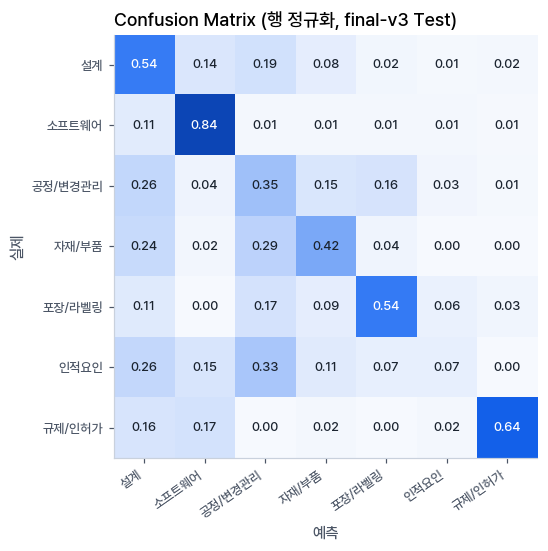

In [15]:
pred_te = np.array(rt.classes)[Ps.argmax(1)]
rep = pd.DataFrame(classification_report(te.root_cause_group.values, pred_te, output_dict=True, zero_division=0)).T.round(3)
display(rep.loc[CLASSES + ["macro avg", "weighted avg"], ["precision", "recall", "f1-score", "support"]])
cmx = confusion_matrix(te.root_cause_group.values, pred_te, labels=CLASSES); cmn = cmx / cmx.sum(1, keepdims=True)
fig, ax = plt.subplots(figsize=(6.2, 5)); ax.imshow(cmn, cmap=cm, vmin=0, vmax=0.9)
for i in range(7):
    for j in range(7): ax.text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center", fontsize=8.5, color="white" if cmn[i, j] > 0.45 else "#1B2430")
ax.set_xticks(range(7)); ax.set_xticklabels(CLASSES, rotation=35, ha="right", fontsize=8.5); ax.set_yticks(range(7)); ax.set_yticklabels(CLASSES, fontsize=8.5)
ax.set_xlabel("예측"); ax.set_ylabel("실제"); ax.set_title("Confusion Matrix (행 정규화, final-v3 Test)", loc="left"); plt.show()

### 3.6 [보고값] 소수 클래스(인적요인) 증강 — 최종 모델에는 포함하지 않음
인적요인은 학습 데이터가 669건뿐이라 Claude로 Paraphrase 689건·Synthetic 299건을 만들어 비교했습니다. 이 증강 데이터와 모델은 **실행 가능한 아티팩트가 저장소에 없어 재계산하지 않았습니다**.

| 단계 | 인적요인 F1 | Macro F1 | 검정 | 판단 |
|---|---|---|---|---|
| 1단계 과거 7-class (Test 1,050) | 0.033 → 0.074 | 0.4395 → 0.4499 | McNemar p=0.332 / Bootstrap CI [+0.0007, +0.0237] | 후보 채택 |
| 2단계 보완 6-class (튜터 피드백 후) | 0.068 → 0.120 | 0.4838 → 0.4930 | p=0.26 / CI [−0.0057, +0.0256] (0 포함) | **확정 불가** |

→ 방향은 있었지만 **통계적으로 확정하지 못했고**(인적요인 Test 27건), 최종 모델에는 넣지 않고 **대시보드에서 인적요인 예측에 별도 경고**를 보여줍니다.

### 3.7 [보고값] 시도했지만 채택하지 않은 것
| 시도 | 결과 | 판단 |
|---|---|---|
| Sentence Embedding 단독 | Macro F1 0.3888 (TF-IDF보다 낮음) | 분류에는 미사용, 검색에 사용 |
| TF-IDF + Embedding Hybrid | 0.4396, CI [−0.0207, +0.0261] | 개선으로 보기 어려움 |
| 정형 정보(Product Code 등) 결합 | 텍스트 단독을 넘지 못함 | 화면 참고 정보로 |
| Cleanlab 라벨 정제 | 제거 시 0.4838 → 0.4723 | 자동 적용 안 함 |
| 클래스 통합 | 0.48 → 0.57은 저성능 클래스가 평균에서 빠진 효과 | 7-class 유지 |
| 정형 증강(SMOTE·CTGAN) | Original(0.2615)을 넘지 못함 | 효과 없음 |

## 4. 오류 분석 — 모델은 어디서, 왜 틀리는가?
여기서부터는 프로젝트가 저장한 예측(`confidence_predictions.csv`, 위에서 저장 모델과 일치 확인)을 사용합니다.
### 4.1 [재계산] Top-k: 정답을 하나로 못 맞혀도 후보로 쓸 수 있는가?

,클래스,n,Top-1,Top-2,Top-3
0,전체,1042,50.48,76.97,89.92
1,공정/변경관리,382,34.82,71.73,91.88
2,규제/인허가,58,63.79,81.03,89.66
3,설계,248,54.03,83.06,91.53
4,소프트웨어,186,84.41,93.55,96.24
5,인적요인,27,7.41,29.63,44.44
6,자재/부품,106,41.51,65.09,83.96
7,포장/라벨링,35,54.29,68.57,77.14


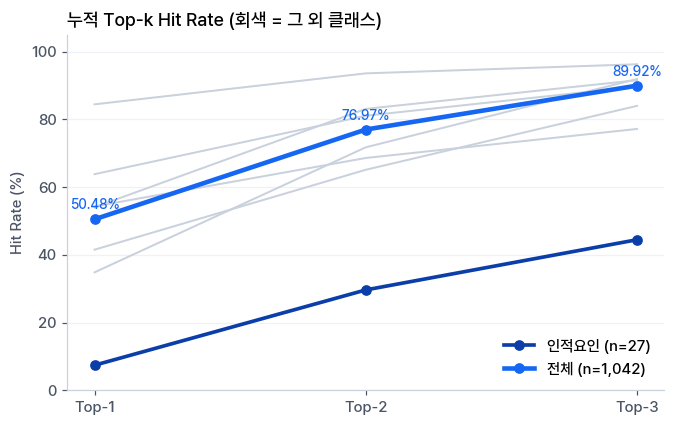

In [16]:
T = pred_file[pred_file.split == "TEST"]; V = pred_file[pred_file.split == "VALIDATION"]
def topk(d): return [d.correct.mean() * 100, d.top2_hit.mean() * 100, d.top3_hit.mean() * 100]
tk = pd.DataFrame([("전체", len(T), *topk(T))] + [(c, len(g), *topk(g)) for c, g in T.groupby("true_label")], columns=["클래스", "n", "Top-1", "Top-2", "Top-3"]).round(2)
display(tk)
fig, ax = plt.subplots(figsize=(7, 4.2)); xs = [1, 2, 3]
for c, g in T.groupby("true_label"):
    if c != "인적요인": ax.plot(xs, topk(g), color=LG, lw=1.3)
ax.plot(xs, topk(T[T.true_label == "인적요인"]), color=DEEP, lw=2.4, marker="o", label="인적요인 (n=27)")
ax.plot(xs, topk(T), color=BLUE, lw=3, marker="o", label=f"전체 (n={len(T):,})")
for x, y in zip(xs, topk(T)): ax.text(x, y + 3, f"{y:.2f}%", ha="center", color=BLUE, fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(["Top-1", "Top-2", "Top-3"]); ax.set_ylim(0, 105); ax.set_ylabel("Hit Rate (%)"); ax.grid(axis="y", color="#EEF2F8"); ax.legend(frameon=False)
ax.set_title("누적 Top-k Hit Rate (회색 = 그 외 클래스)", loc="left"); plt.show()

**발견**: 전체 Top-1 50.48% → Top-3 89.92%. 인적요인은 Top-3에서도 44.44%로 낮습니다.
**해석 주의**: Top-k 상승은 모델이 좋아졌다는 뜻이 아니라 **정답이 후보 안에 포함될 가능성(coverage)이 커졌다**는 뜻입니다.

### 4.2 [재계산] 틀린 사례는 어디에 있었나? 헷갈리는 쌍은?

In [17]:
wrong = T[~T.correct]
r2 = int(wrong.top2_hit.sum()); r3 = int(wrong.top3_hit.sum())
print(f"Top-1 오답 {len(wrong)}건 중 Top-2에서 구제 {r2}건 ({r2/len(wrong)*100:.1f}%), Top-3까지 구제 {r3}건 ({r3/len(wrong)*100:.1f}%), Top-3에도 없음 {len(wrong)-r3}건")
rows_ = []
for a_, b_ in [("설계", "공정/변경관리"), ("공정/변경관리", "설계")]:
    g = T[(T.true_label == a_) & (T.predicted_label == b_)]
    rows_.append((f"{a_} → {b_}로 예측", len(g), int(g.top2_hit.sum()), g.top2_hit.mean() * 100))
display(pd.DataFrame(rows_, columns=["혼동 쌍(Top-1 기준)", "n", "Top-2에 정답 포함", "비율(%)"]).round(1))

Top-1 오답 516건 중 Top-2에서 구제 276건 (53.5%), Top-3까지 구제 411건 (79.7%), Top-3에도 없음 105건


,혼동 쌍(Top-1 기준),n,Top-2에 정답 포함,비율(%)
0,설계 → 공정/변경관리로 예측,46,29,63.0
1,공정/변경관리 → 설계로 예측,100,62,62.0


### 4.3 [보고값] 오류의 원인 — 설계 ↔ 공정/변경관리 오분류 100건 직접 진단 (튜터 피드백 후)
| 오류 원인 | 비율 | 의미 |
|---|---|---|
| 입력 정보 부족 (INPUT_INSUFFICIENT) | 46% | 텍스트에 실제·예측 클래스를 가리키는 단서가 없음 |
| 분류체계 모호 (TAXONOMY_AMBIGUOUS) | 19% | 설계 ↔ 공정/변경관리처럼 경계가 모호 |
| 모델 오류 (MODEL_ERROR) | 19% | 텍스트가 정답을 가리키는데 모델이 놓침 |
| 라벨 의심 (LABEL_SUSPECT) | 16% | 텍스트는 예측을 가리키는데 원본 라벨이 다름 |

### 4.4 방향 전환
> 입력 정보 부족 + 분류체계 모호 = **65%** → 모델을 바꿔도 풀리지 않는 문제.
> 정확도를 더 올리는 대신 **"단일 정답 분류기" → "후보(Top-3) + Confidence + 과거 근거 + 사람의 판단"** 구조로 목표를 재정의했습니다.
> (작은 검증 3가지, Validation: Top-k 후보가 유용하다 / Confidence가 난이도를 구분한다 / 유사 검색이 참고 근거가 된다.)

## 5. Confidence 분석 — 분석 → threshold → 검증 → 한계
**정의**: Confidence = 모델이 1위로 예측한 Root Cause의 확률(Top-1 확률). **HIGH ≥ 0.6 / MEDIUM 0.3~<0.6 / LOW < 0.3**.
정책 파일(`artifacts/confidence/confidence_policy.json`)에는 임계값을 Validation에서 선택했고 Test에는 변경 없이 적용했다고 기록되어 있습니다.
### 5.1 [재계산] Confidence 분포

임계값: {'high_threshold': 0.6, 'low_threshold': 0.3} | 상태: PROVISIONAL_VALIDATED


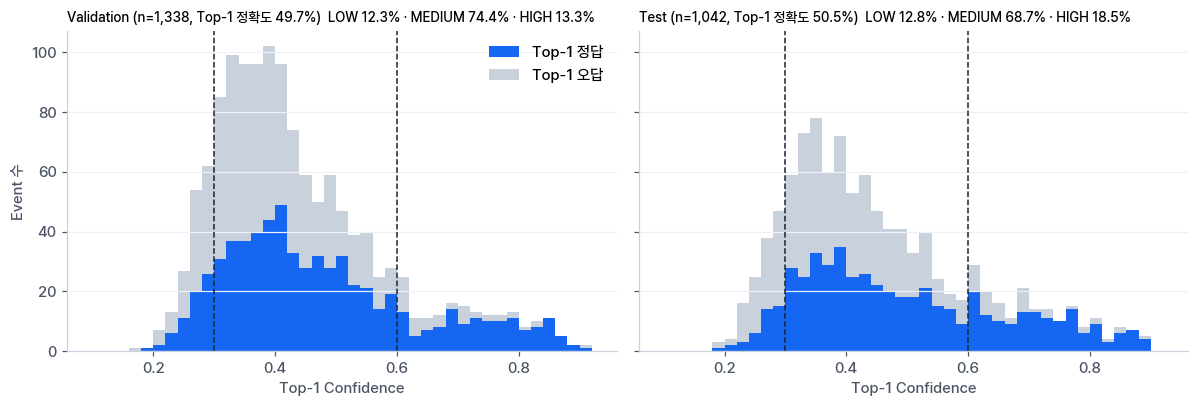

In [18]:
policy = json.loads((ROOT / "artifacts/confidence/confidence_policy.json").read_text(encoding="utf-8"))
print("임계값:", policy.get("thresholds", {k: policy.get(k) for k in ("high_threshold", "low_threshold")}), "| 상태:", policy.get("status", policy.get("policy_status")))
bins = np.arange(0.10, 0.94, 0.02)
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, d, nm in zip(axs, [V, T], ["Validation", "Test"]):
    h1, _ = np.histogram(d[d.correct].confidence, bins); h0, _ = np.histogram(d[~d.correct].confidence, bins)
    ax.bar(bins[:-1], h1, width=0.02, align="edge", color=BLUE, label="Top-1 정답"); ax.bar(bins[:-1], h0, width=0.02, align="edge", bottom=h1, color=LG, label="Top-1 오답")
    for t_ in (0.3, 0.6): ax.axvline(t_, color="#1B2430", ls="--", lw=1)
    cov = [(d.confidence < 0.3).mean() * 100, ((d.confidence >= 0.3) & (d.confidence < 0.6)).mean() * 100, (d.confidence >= 0.6).mean() * 100]
    ax.set_title(f"{nm} (n={len(d):,}, Top-1 정확도 {d.correct.mean()*100:.1f}%)  LOW {cov[0]:.1f}% · MEDIUM {cov[1]:.1f}% · HIGH {cov[2]:.1f}%", loc="left", fontsize=9)
    ax.set_xlabel("Top-1 Confidence"); ax.grid(axis="y", color="#EEF2F8")
axs[0].set_ylabel("Event 수"); axs[0].legend(frameon=False); plt.tight_layout(); plt.show()

### 5.2 [재계산] Validation에서 threshold를 바꾸면 정확도와 Coverage는 어떻게 변하는가?

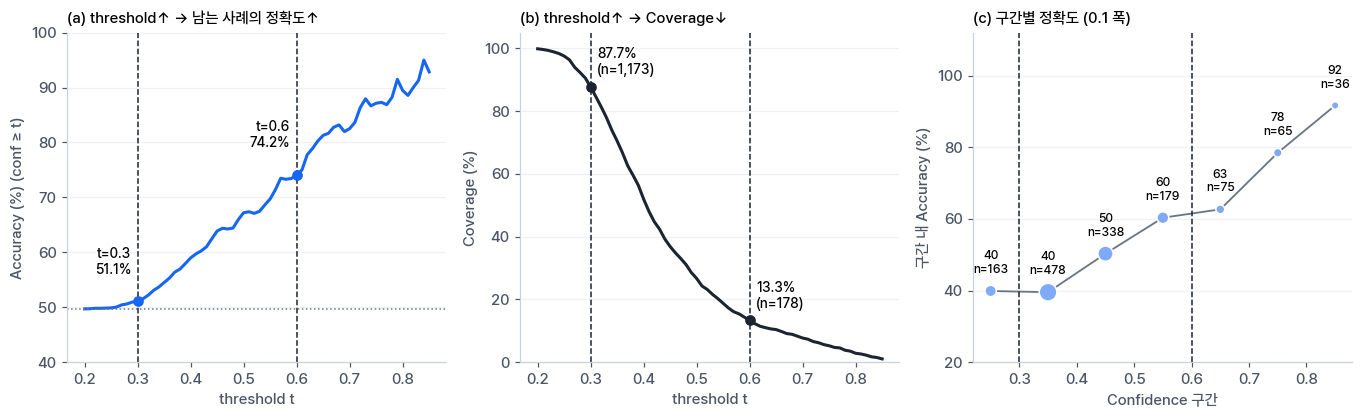

t,0.3,0.4,0.5,0.6,0.7,0.8
accuracy,51.1,59.0,67.2,74.2,82.5,89.5
coverage,87.7,51.9,26.7,13.3,7.7,2.8
n,1173.0,695.0,357.0,178.0,103.0,38.0


In [19]:
ths = np.round(np.arange(0.20, 0.851, 0.01), 2)
sweep = pd.DataFrame({"t": ths, "accuracy": [V[V.confidence >= t].correct.mean() * 100 for t in ths],
                      "coverage": [(V.confidence >= t).mean() * 100 for t in ths], "n": [int((V.confidence >= t).sum()) for t in ths]})
binlo = np.round(np.arange(0.2, 0.9, 0.1), 1)
bacc = pd.DataFrame({"bin": binlo, "accuracy": [V[(V.confidence >= lo) & (V.confidence < lo + 0.1)].correct.mean() * 100 for lo in binlo],
                     "n": [int(((V.confidence >= lo) & (V.confidence < lo + 0.1)).sum()) for lo in binlo]})
fig, axs = plt.subplots(1, 3, figsize=(12.5, 3.9))
a, b, c = axs
a.plot(sweep.t, sweep.accuracy, color=BLUE, lw=2); a.axhline(V.correct.mean() * 100, color=GRAY, ls=":", lw=1)
b.plot(sweep.t, sweep.coverage, color="#1B2430", lw=2)
for t_ in (0.3, 0.6):
    for ax in (a, b): ax.axvline(t_, color="#1B2430", ls="--", lw=1)
    r = sweep[sweep.t == t_].iloc[0]; a.scatter([t_], [r.accuracy], color=BLUE, zorder=4); b.scatter([t_], [r.coverage], color="#1B2430", zorder=4)
    a.text(t_ - 0.012, r.accuracy + 5, f"t={t_}\n{r.accuracy:.1f}%", ha="right", fontsize=9); b.text(t_ + 0.012, r.coverage + 4, f"{r.coverage:.1f}%\n(n={int(r.n):,})", fontsize=9)
c.plot(bacc.bin + 0.05, bacc.accuracy, color=GRAY, lw=1.2); c.scatter(bacc.bin + 0.05, bacc.accuracy, s=bacc.n / 4 + 15, color=MID, edgecolor="white", zorder=3)
for x_, y_, n_ in zip(bacc.bin + 0.05, bacc.accuracy, bacc.n): c.text(x_, y_ + 5, f"{y_:.0f}\nn={n_}", ha="center", fontsize=8)
for t_ in (0.3, 0.6): c.axvline(t_, color="#1B2430", ls="--", lw=1)
a.set_title("(a) threshold↑ → 남는 사례의 정확도↑", loc="left", fontsize=10); a.set_xlabel("threshold t"); a.set_ylabel("Accuracy (%) (conf ≥ t)"); a.set_ylim(40, 100)
b.set_title("(b) threshold↑ → Coverage↓", loc="left", fontsize=10); b.set_xlabel("threshold t"); b.set_ylabel("Coverage (%)"); b.set_ylim(0, 105)
c.set_title("(c) 구간별 정확도 (0.1 폭)", loc="left", fontsize=10); c.set_xlabel("Confidence 구간"); c.set_ylabel("구간 내 Accuracy (%)"); c.set_ylim(20, 112)
for ax in axs: ax.grid(axis="y", color="#EEF2F8")
plt.tight_layout(); plt.show()
display(sweep[sweep.t.isin([0.3, 0.4, 0.5, 0.6, 0.7, 0.8])].round(1).set_index("t").T)

**관찰 (정직하게)**: threshold를 높일수록 정확도는 오르고 Coverage는 줄어드는 **trade-off**가 분명합니다. 그러나 (c)에서 보듯 **구간별 정확도는 한 지점에서 급격히 꺾이지 않고 완만하게 올라갑니다**.
따라서 0.6·0.3은 "통계적 최적점"이 아니라, **HIGH로 분류되는 사례의 크기와 정확도를 함께 본 운영 기준**입니다. (특히 0.3 하한은 Validation에서 [0.2,0.3) 구간 정확도와 [0.3,0.4) 구간 정확도가 거의 같아 근거가 약하며, 근거 문서화는 남은 과제입니다.)

### 5.3 [재계산] Risk–Coverage: 어떤 사례를 모델에 맡기고 어떤 사례를 사람이 더 봐야 하는가?

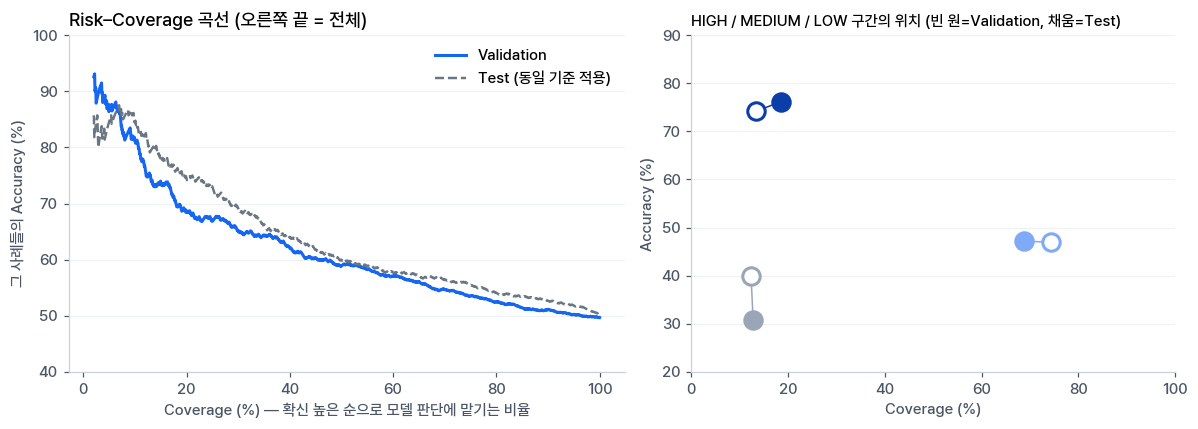

,split,level,coverage,accuracy
0,Validation,HIGH,13.30,74.16
1,Validation,MEDIUM,74.36,46.93
2,Validation,LOW,12.33,40.00
3,Test,HIGH,18.52,76.17
4,Test,MEDIUM,68.71,47.21
5,Test,LOW,12.76,30.83


In [20]:
def risk_coverage(d):
    s = d.sort_values("confidence", ascending=False).reset_index(drop=True)
    return (np.arange(1, len(s) + 1) / len(s) * 100), (s.correct.cumsum() / np.arange(1, len(s) + 1) * 100).values
cvV, acV = risk_coverage(V); cvT, acT = risk_coverage(T)
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.15, 1]})
k = slice(int(len(V) * 0.02), None); kt = slice(int(len(T) * 0.02), None)
a.plot(cvV[k], acV[k], color=BLUE, lw=2, label="Validation"); a.plot(cvT[kt], acT[kt], color=GRAY, lw=1.6, ls="--", label="Test (동일 기준 적용)")
a.set_xlabel("Coverage (%) — 확신 높은 순으로 모델 판단에 맡기는 비율"); a.set_ylabel("그 사례들의 Accuracy (%)"); a.set_ylim(40, 100); a.legend(frameon=False); a.grid(axis="y", color="#EEF2F8")
a.set_title("Risk–Coverage 곡선 (오른쪽 끝 = 전체)", loc="left")
pts = [(nm, lv, (d.confidence_level == lv).mean() * 100, d[d.confidence_level == lv].correct.mean() * 100) for d, nm in ((V, "Validation"), (T, "Test")) for lv in ("HIGH", "MEDIUM", "LOW")]
P = pd.DataFrame(pts, columns=["split", "level", "coverage", "accuracy"]); colr = {"HIGH": DEEP, "MEDIUM": MID, "LOW": "#9AA6B8"}
for _, r in P.iterrows(): b.scatter(r.coverage, r.accuracy, s=130, facecolor="white" if r.split == "Validation" else colr[r.level], edgecolor=colr[r.level], lw=2, zorder=3)
for lv in colr: g = P[P.level == lv]; b.plot(g.coverage, g.accuracy, color=colr[lv], lw=1)
b.set_xlabel("Coverage (%)"); b.set_ylabel("Accuracy (%)"); b.set_xlim(0, 100); b.set_ylim(20, 90); b.grid(axis="y", color="#EEF2F8"); b.set_title("HIGH / MEDIUM / LOW 구간의 위치 (빈 원=Validation, 채움=Test)", loc="left", fontsize=10)
plt.tight_layout(); plt.show(); display(P.round(2))

### 5.4 [재계산] Validation에서 정한 기준이 Test에서도 유지되는가?

In [21]:
pv = P.pivot(index="level", columns="split", values="accuracy").loc[["HIGH", "MEDIUM", "LOW"]]
pc = P.pivot(index="level", columns="split", values="coverage").loc[["HIGH", "MEDIUM", "LOW"]]
out = pd.concat({"Accuracy (%)": pv, "Coverage (%)": pc}, axis=1).round(2); display(out)
for sp in ("Validation", "Test"):
    ok = pv[sp]["HIGH"] > pv[sp]["MEDIUM"] > pv[sp]["LOW"]; print(f"{sp}: HIGH > MEDIUM > LOW 순서 유지 = {ok}")

Accuracy (%)            Coverage (%)           
split          Test Validation         Test Validation
level                                                 
HIGH          76.17      74.16        18.52      13.30
MEDIUM        47.21      46.93        68.71      74.36
LOW           30.83      40.00        12.76      12.33

Validation: HIGH > MEDIUM > LOW 순서 유지 = True
Test: HIGH > MEDIUM > LOW 순서 유지 = True


**결과**: 같은 threshold(0.3 / 0.6)를 변경 없이 Test에 적용해도 **HIGH > MEDIUM > LOW 순서가 유지**됩니다. 다만 LOW의 정확도가 40.0% → 30.8%로 달라 **구간 안의 정확한 값은 표본에 따라 흔들릴 수 있습니다**.

### 5.5 [재계산] Confidence를 확률로 믿어도 되는가? (Calibration)

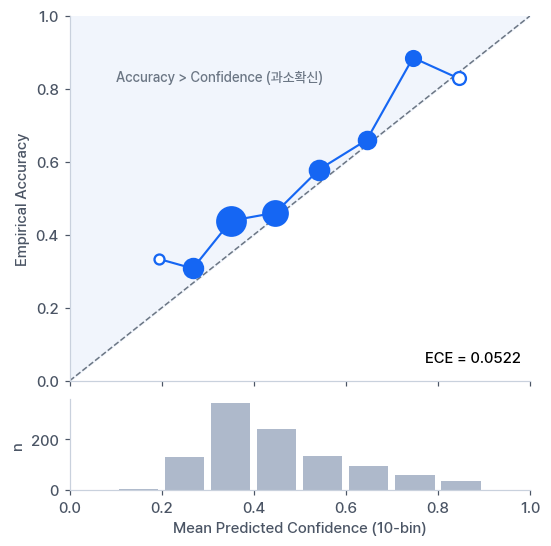

[재계산] ECE(10-bin) = 0.0522 | 평균 Confidence = 0.4537 | 실제 Accuracy = 0.5048  (빈 원 = 구간 내 n<50)
정책 파일 기록: {'test_accuracy': 0.5047984644913628, 'test_mean_confidence': 0.45365694236416165, 'ece_10bin': 0.05223467406350345}


,root_cause,confidence_level,support,n,coverage,mean_confidence,top1_accuracy,top3_hit_rate
0,인적요인,ALL,27,27,1.000,0.412,0.074,0.444
1,인적요인,HIGH,27,4,0.148,0.672,0.000,0.250
2,인적요인,MEDIUM,27,16,0.593,0.411,0.062,0.438
3,인적요인,LOW,27,7,0.259,0.266,0.143,0.571


In [22]:
edges = np.linspace(0, 1, 11); rel = []
for i in range(10):
    m = (T.confidence >= edges[i]) & ((T.confidence < edges[i + 1]) | ((i == 9) & (T.confidence <= 1)))
    if m.sum(): rel.append((edges[i], int(m.sum()), T[m].confidence.mean(), T[m].correct.mean()))
R_ = pd.DataFrame(rel, columns=["lo", "n", "mean_conf", "acc"])
ece = sum(r.n / len(T) * abs(r.acc - r.mean_conf) for r in R_.itertuples())
fig, (a, h) = plt.subplots(2, 1, figsize=(5.4, 5.6), sharex=True, gridspec_kw={"height_ratios": [4, 1], "hspace": 0.08})
a.plot([0, 1], [0, 1], color=GRAY, ls="--", lw=1); a.fill_between([0, 1], [0, 1], [1, 1], color="#F1F5FC", zorder=0)
a.plot(R_.mean_conf, R_.acc, color=BLUE, lw=1.4)
for r in R_.itertuples(): a.scatter(r.mean_conf, r.acc, s=40 + r.n * 0.9, facecolor="white" if r.n < 50 else BLUE, edgecolor=BLUE, lw=1.5, zorder=3)
a.text(0.1, 0.82, "Accuracy > Confidence (과소확신)", fontsize=9, color=GRAY); a.text(0.98, 0.05, f"ECE = {ece:.4f}", ha="right", fontsize=10)
a.set_ylabel("Empirical Accuracy"); a.set_xlim(0, 1); a.set_ylim(0, 1)
h.bar((R_.lo + 0.05), R_.n, width=0.085, color="#AEB9CB"); h.set_ylabel("n"); h.set_xlabel("Mean Predicted Confidence (10-bin)")
plt.show()
print(f"[재계산] ECE(10-bin) = {ece:.4f} | 평균 Confidence = {T.confidence.mean():.4f} | 실제 Accuracy = {T.correct.mean():.4f}  (빈 원 = 구간 내 n<50)")
print("정책 파일 기록:", {k: v for k, v in json.loads((ROOT / "out/day15_final_v3_confidence_revalidation/calibration_summary.json").read_text(encoding="utf-8")).items() if k in ("ece_10bin", "test_mean_confidence", "test_accuracy")})
hf = pd.read_csv(ROOT / "out/day15_final_v3_confidence_revalidation/human_factor_confidence_summary.csv"); display(hf.round(3))

**결론**: 대부분의 구간이 대각선 위(**과소확신**)에 있고 ECE는 0.0522지만, 구간별 표본이 작은 곳이 있고 **보정(calibration)을 적용하지 않았습니다**.
인적요인 정답 27건 중 4건은 HIGH로 예측됐지만 Top-1은 모두 오답이었습니다(위 표).
→ Confidence는 **정답 확률이 아니라 "얼마나 더 살펴볼지"의 검토 우선순위 신호**이며, HIGH여도 **자동 승인에 쓰지 않습니다.** (정책 상태: `PROVISIONAL_VALIDATED`)

### 5.6 Confidence 기준 선정 논리 (요약)
1. Confidence 분포 확인 → 2. Validation에서 threshold sweep → 3. Accuracy–Coverage trade-off 확인 → 4. HIGH ≥ 0.6 / LOW < 0.3 기준 설정(운영 기준)
→ 5. Test에 **변경 없이 적용** → 6. HIGH > MEDIUM > LOW 순서 확인 → 7. 확률이 아닌 검토 우선순위로 해석(ECE 0.0522) → 8. 자동 승인 없음, Human QA 최종 판단

**기각한 규칙 [보고값, 과거 스냅샷]**: ① "예측이 소프트웨어면 무조건 검토" → 운영 중에는 정답을 알 수 없어 사용 불가 ② Top-1·Top-2 "위험 시그니처" 규칙 → 해당 212건 중 108건이 정상 사례, 고확신 구간 정확도 79.6% vs 78.6%로 차이 없음.

## 6. 유사 Recall 검색 (Recall Reason → 과거 근거)
검색은 Root Cause를 맞히는 기능이 아니라 **QA가 조사 범위를 좁히도록 근거를 제시**하는 기능입니다.
### 6.1 설계와 기준 (저장소의 `artifacts/retrieval/retrieval_config.json`)

In [23]:
rcfg = json.loads((ROOT / "artifacts/retrieval/retrieval_config.json").read_text(encoding="utf-8"))
print(json.dumps({k: rcfg[k] for k in list(rcfg)[:14]}, ensure_ascii=False, indent=1)[:1800])

{
 "version": "day14-semantic-retrieval-1",
 "status": "CURRENT_CANDIDATE",
 "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
 "embedding_dimension": 384,
 "normalize_embeddings": true,
 "similarity": "cosine",
 "corpus_role": "historical_train_only",
 "corpus_data": "out/event_features_integrated_v3.csv",
 "corpus_event_ids": "modeling/01_sentence_embedding/artifacts/train_event_ids.npy",
 "train_embeddings": "modeling/01_sentence_embedding/artifacts/train_embeddings.npy",
 "event_metadata_source": "out/event_features_integrated_v3.csv",
 "data_snapshot": "integrated_v3",
 "snapshot_verification": {
  "train_rows": 13645,
  "validation_rows": 1338,
  "test_rows": 1042,
  "embedding_event_id_alignment": true,
  "status": "FINAL"
 },
 "date_leakage_rule": "retrieved_event_date < query_event_date"
}


* 임베딩 `all-MiniLM-L6-v2`(384차원) + 코사인 유사도, 검색 대상은 **Train 13,645건만**, **개시일 < 검색 기준일** 사례만, 입력 Event 자기 자신 제외, 기본 Top-3(더 보기 최대 5).
* Hard Filter·Reranking은 쓰지 않습니다(수동 7건 검토만으로는 근거 부족).
* 분류에서는 임베딩이 TF-IDF보다 낮았지만(0.3888 vs 0.4373 **[보고값]**) 의미 유사 검색에는 적합해 **검색에만** 사용합니다.
* **개시일 기준 필터링 ≠ 실제 정보 공개 시점 검증**: 필터는 "개시일 < 기준일"만 보장하며, 당시 해당 정보가 실제로 공개되어 있었는지는 검증하지 않았습니다.

### 6.2 [재계산] 검색 로직 시연 (저장된 Train 임베딩 사용)
저장소에는 Train 임베딩(`train_embeddings.npy`)만 있어, 아래는 **Train 내부 질의로 날짜 필터·자기 제외 로직을 보여주는 시연**입니다(검색 성능 평가가 아닙니다).

In [24]:
emb = np.load(ROOT / "modeling/01_sentence_embedding/artifacts/train_embeddings.npy")
ids = np.load(ROOT / "modeling/01_sentence_embedding/artifacts/train_event_ids.npy", allow_pickle=True).astype(int)
ev_idx = ev.set_index("res_event_number")
dates = pd.to_datetime(ev_idx.loc[ids, "event_date_initiated_clean"]).values
print("임베딩:", emb.shape, "| 정규화 여부(평균 norm):", round(float(np.linalg.norm(emb, axis=1).mean()), 3))

def retrieve(query_pos, k=3):
    sims = emb @ emb[query_pos]
    ok = (dates < dates[query_pos]) & (ids != ids[query_pos])          # 개시일 < 기준일, 자기 Event 제외
    order = np.argsort(-np.where(ok, sims, -9))[:k]
    return [(int(ids[i]), float(sims[i]), ev_idx.loc[ids[i], "root_cause_group"], ev_idx.loc[ids[i], "reason_for_recall_clean"][:80]) for i in order]

qpos = [int(np.where(ids == e)[0][0]) for e in tr[tr.yr == 2021].groupby("root_cause_group").head(1).res_event_number.values[:2]]
for p_ in qpos:
    q = ids[p_]; print(f"\n[질의 Event {q}] ({ev_idx.loc[q, 'root_cause_group']}, {str(dates[p_])[:10]}) {ev_idx.loc[q, 'reason_for_recall_clean'][:90]}")
    out = pd.DataFrame(retrieve(p_), columns=["Event", "Similarity", "과거 Root Cause", "Recall Reason"]); out.insert(0, "Rank", range(1, 4)); display(out.round(4))
    assert all(pd.Timestamp(dates[np.where(ids == e)[0][0]]) < pd.Timestamp(dates[p_]) and e != q for e, *_ in retrieve(p_))
print("\n로직 확인: 모든 검색 결과가 질의 개시일보다 이전이며 자기 자신이 아님 (assert 통과)")

임베딩: (13645, 384) | 정규화 여부(평균 norm): 1.0

[질의 Event 86808] (설계, 2021-02-18) Customers are being notified of results from a Toxicological Risk Assessment related to po


,Rank,Event,Similarity,과거 Root Cause,Recall Reason
0,1,82393,0.5011,설계,Testing has demonstrated aluminum elution from...
1,2,76927,0.4637,설계,"Product may overheat, melt, and burn patient."
2,3,76828,0.4587,설계,Reported customer complaints of automated hema...



[질의 Event 87087] (자재/부품, 2021-01-04) Manufactured with incorrect material, which may result in the stent being stiffer and pote


,Rank,Event,Similarity,과거 Root Cause,Recall Reason
0,1,78587,0.7259,자재/부품,Stent possibly unable to be fully released fro...
1,2,48760,0.7167,공정/변경관리,The bond may break where the two materials mee...
2,3,74097,0.7107,설계,Inability to deploy the stent or partial stent...



로직 확인: 모든 검색 결과가 질의 개시일보다 이전이며 자기 자신이 아님 (assert 통과)


### 6.3 [보고값] 사람이 읽는 수동 평가 (작성자 1인, 전문 QA 검증 아님)
검색 결과가 실제로 쓸모가 있는지는 정확도 대신 **수동 평가(GOOD / PARTIAL / POOR)**로 확인했습니다. 대시보드의 "Retrieval 수동 평가" 패널이 읽는 파일과 같은 요약 데이터입니다.

In [25]:
mr = json.loads((ROOT / "artifacts/retrieval/manual_review_summary.json").read_text(encoding="utf-8"))
print("※", mr["notice"]); print("범위:", mr["scope"])
q, low = mr["query_quality"], mr["low_confidence_queries"]
display(pd.DataFrame([{"구분": f"전체 Query {sum(q.values())}건", "GOOD": q["GOOD"], "PARTIAL": q["PARTIAL"], "POOR": q["POOR"]},
                      {"구분": f"Confidence LOW Query {low['total']}건", "GOOD": low["GOOD"], "PARTIAL": low["PARTIAL"], "POOR": low["POOR"]}]))
display(pd.DataFrame(mr["cases"]).rename(columns={"kind": "구분", "case": "사례", "observation": "검색 결과 관찰", "implication": "시사점"}))

※ 작성자 1인의 수동 평가 요약이며 전문 QA 검증이 아닙니다. GOOD/PARTIAL/POOR 건수는 검색 정확도(%)가 아닙니다. 원본 평가표(CSV)는 이 패키지에 포함되어 있지 않습니다.
범위: final-v3 Validation Query 40건 × 과거 Recall Top-5 = 200쌍. 검색 결과를 확인하기 전에 Query를 확정했고, 이전에 사용한 Query는 제외했으며 Test는 사용하지 않음. Confidence 구성: HIGH 10 · MEDIUM 15 · LOW 15.


,구분,GOOD,PARTIAL,POOR
0,전체 Query 40건,28,7,5
1,Confidence LOW Query 15건,9,4,2


,구분,사례,검색 결과 관찰,시사점
0,성공,스텐트 전달 시스템 문제,거의 같은 failure mode와 당시 조치까지 확인할 수 있었음,유사 사례가 조사 범위를 좁히는 데 도움
1,성공,미신고 라텍스,Specialty·Product Code가 달라도 같은 문제 유형의 사례가 검색됨,제품군이 달라도 문제 유형이 같으면 참고 가능
2,성공,Event 94388 (Confidence LOW),1위가 아닌 Rank 4에서 같은 제품코드·같은 회사·같은 SSD 문제 사례가 검색됨,Top-1만 보지 않고 Top-5를 확인하는 이유
3,부분 성공,Event 95066 (용접 누락),같은 결함 현상은 찾았지만 제품군이 달라 직접 비교에는 제한,PARTIAL: 보조 참고 수준
4,실패·한계,Query 92874 (LCD 구리 테이프),Top-1 Similarity 0.7542로 높았지만 제품 맥락이 달라 POOR (...,높은 유사도가 좋은 근거를 보장하지 않음
5,실패·한계,"Event 92619 (""Software issue"")",Similarity 1.0이지만 문장이 너무 일반적이라 원인을 좁힐 정보가 없었음,입력 정보가 부족하면 검색 근거도 약함
6,실패·한계,Event 92825 (burr),같은 단어(burr)여도 혈관 채취용 커터와 골절삭용 버가 섞임,단어가 같아도 제품·용도 맥락을 함께 읽어야 함


**발견**: 유사도가 높아도 제품·결함 맥락이 다르면 쓸모가 없었고(예: Similarity 0.7542인데 POOR), 1위가 아닌 Rank 4에서 가장 좋은 사례가 나오기도 했습니다.
→ 유사도는 **참고 점수로만** 보여주고, 최종 판단은 사람이 합니다. 이 숫자를 **"검색 정확도 70%"로 해석하지 않습니다.**

## 7. 대시보드 통합
### 7.1 구조
```
입력(Recall Reason + 검색 기준일)
   ├─ classification/  Word+Char TF-IDF + SGD → Top-3, Confidence(Top-1 확률)
   ├─ retrieval/       MiniLM 임베딩 → 개시일 < 기준일 · 자기 제외 → Top-3(+더 보기 5)
   └─ pipeline/        두 모듈 통합 + QA 검토 체크리스트(Day16/qa_checklist.py)
dashboard/            Streamlit 화면 어댑터(XAI 키워드 요약, 후보별 확인 포인트) + UI + Human QA 판단 기록
app_design_prototype.py / streamlit_app.py   진입점
```
화면은 **AI 분석 결과 / 과거 사례·근거 / QA 검토·판단** 3개 영역이며, 모든 화면에 *QA Review: Required*가 표시됩니다.

### 7.2 [재계산] 분류·Confidence·XAI 런타임 시연 (저장 모델 사용)
final-v3 Test에서 **Confidence가 HIGH/LOW로 저장된 실제 사례**를 대시보드와 같은 런타임에 넣어봅니다.

In [26]:
from dashboard import day21_prototype_adapter as adapter
from dashboard import day21_prototype_workflow as workflow
samples = {"HIGH 사례 (Test Event 96055)": ev_idx.loc[96055, "reason_for_recall_clean"], "LOW 사례 (Test Event 96075)": ev_idx.loc[96075, "reason_for_recall_clean"]}
for name, text in samples.items():
    r = rt.classify(text); xai = adapter._xai_explain(rt, text, r["top1_root_cause"])
    print("=" * 78); print(name, "| 실제 정답:", ev_idx.loc[int(name.split()[-1].rstrip(')')), "root_cause_group"])
    print("입력:", text[:110], "...")
    print("Top-3:", [(c["root_cause"], round(c["probability"], 3)) for c in r["top3_candidates"]])
    print(f"Confidence: {r['confidence_level']} ({r['top1_confidence']:.3f}) | 저장된 예측 파일 값: {TEST.loc[int(name.split()[-1].rstrip(')')), 'confidence']:.3f}")
    print("모델 예측 근거(규칙 기반 요약):", xai["natural_summary"], "| 키워드:", xai["top_words"])
    print("Review Guidance:", workflow.GUIDANCE[r["confidence_level"]])
    print("후보별 확인 포인트:", {c["root_cause"]: adapter.REQUIRED_INFO[c["root_cause"]][:2] for c in r["top3_candidates"]})

HIGH 사례 (Test Event 96055) | 실제 정답: 소프트웨어
입력: Software issues could potentially result in: 1) delays in accessing dispensing software application, 2) wrong  ...
Top-3: [('소프트웨어', 0.764), ('규제/인허가', 0.096), ('설계', 0.056)]
Confidence: HIGH (0.764) | 저장된 예측 파일 값: 0.764
모델 예측 근거(규칙 기반 요약): Recall Reason에서 소프트웨어 기능 이상 및 표시/데이터 처리 오류와 관련된 표현이 확인됨 | 키워드: ['software', 'dose', 'application', 'wrong', 'access']
Review Guidance: ['Top-3 후보와 유사 Recall을 함께 비교하세요.', '핵심 근거를 확인하세요. HIGH도 자동 승인 기준이 아닙니다.']
후보별 확인 포인트: {'소프트웨어': ['SW/Firmware Version', '변경 이력'], '규제/인허가': ['허가/승인 번호', '규제 변경 이력'], '설계': ['설계 변경 이력', '설계 사양']}
LOW 사례 (Test Event 96075) | 실제 정답: 공정/변경관리
입력: Devices presented a condition in which the inner needle separated from the hub and produced a longer throw of  ...
Top-3: [('자재/부품', 0.272), ('공정/변경관리', 0.259), ('설계', 0.244)]
Confidence: LOW (0.272) | 저장된 예측 파일 값: 0.272
모델 예측 근거(규칙 기반 요약): Recall Reason에서 'produced, hub, condition'와 유사한 표현이 확인됨 | 키워드: ['produced', 'hub', 'condition',

### 7.3 전체 파이프라인 (분류 + 유사 Recall 검색)
`sentence-transformers`가 설치되고 MiniLM 모델을 내려받을 수 있는 환경에서는 아래 셀이 대시보드와 **동일한 통합 런타임**을 실행합니다. 그렇지 않으면 건너뜁니다.

In [27]:
try:
    import sentence_transformers  # noqa: F401
    runtime = adapter.create_runtime(str(ROOT))
    out = runtime.analyze_with_review(samples["LOW 사례 (Test Event 96075)"], "2026-10-06", None)
    disp = adapter.extract_display_result(out)
    print("status:", disp["status"], "| Confidence:", disp["classification"]["confidence_level"], "| 검색 결과:", disp["retrieval"]["returned_n"], "건 | 날짜 필터:", disp["retrieval"]["date_filter_applied"])
    display(pd.DataFrame(disp["retrieval"]["default_results"])[["rank", "retrieved_event_id", "similarity", "retrieved_root_cause", "retrieved_date"]].round(4))
except Exception as e:  # sentence-transformers 미설치 또는 MiniLM 모델을 내려받을 수 없는 환경(오프라인)
    print(f"전체 파이프라인 셀을 건너뜁니다 ({type(e).__name__}). sentence-transformers 설치와 MiniLM 모델 다운로드(인터넷)가 필요합니다.")

전체 파이프라인 셀을 건너뜁니다 (OSError). sentence-transformers 설치와 MiniLM 모델 다운로드(인터넷)가 필요합니다.


### 7.4 Human QA 판단 규칙과 버전 관리 (v1 → v2)
튜터 피드백을 반영해 **v1(최초 설계)**에서 **v2(유지보수 버전)**로 개선했습니다. 저장소에는 `v1.0` / `v2.0` Git 태그와 `CHANGELOG_v2.md`가 있습니다.

| 피드백 | v1 | v2 |
|---|---|---|
| 정보구조 간소화 | 탭 4개 + 하단 판단 영역 | 탭 3개: **AI 분석 결과 / 과거 사례·근거 / QA 검토·판단**, 검증 정보는 접이식 |
| Human QA 판단 독립성 | 최종 Root Cause 기본값 = AI Top-1 | **기본값 미선택**, AI와 같은 원인 선택 시 명시적 확인 + **같은/다른 원인 모두 판단 근거 필수** |
| Retrieval 근거 신뢰성 | 수동 평가 "자료 없음" | 수동 평가 요약(GOOD 28 / PARTIAL 7 / POOR 5)과 대표 사례, **개시일 필터링 ≠ 정보 공개 시점 검증** 구분 |
| 시연 검증 · 과장 방지 | - | AI≠QA·Confidence LOW 시나리오 검증 24항목, **영구 감사 추적(Audit Trail) 아님** 명시 |
| 시스템 소개 페이지 | 컬럼 flex 강제 + 고정 높이 충돌 | 하나의 CSS grid로 같은 행 패널 높이 자동 일치 |

시나리오 검증은 `python tests/test_v2_feedback.py`로 재현합니다(Streamlit AppTest, 실제 저장 모델로 분류).

### 7.5 실행 방법
```bash
pip install -r requirements.txt
streamlit run streamlit_app.py          # 대시보드
python tests/test_v2_feedback.py        # v2 시나리오 검증
```

## 8. 결론, 한계, 향후 과제
**결론**
* EDA로 분석 단위(Event), 평가 방식(시간 기준 분할), 적용 범위(확정 사례 기반)를 정했고, 모델은 **Word+Char TF-IDF + SGD**(final-v3 Test Accuracy 50.48%, Macro F1 0.4496, Top-3 89.92%)를 기준 모델로 연결했습니다.
* 여러 모델·기법을 비교했지만 **통계적으로 확인된 안정적 개선은 없었고**, 오분류의 65%가 입력 정보 부족·분류체계 모호라는 진단에 따라 **단일 정답 분류기가 아니라 "후보 + Confidence + 과거 근거 + Human QA 판단"** 구조로 방향을 바꿨습니다.

**한계**
* 인적요인은 Top-3에서도 44.44%(Test 27건)로 약하고, 증강 효과는 통계적으로 확정하지 못했습니다.
* Word+Char의 우위는 확정적이지 않으며(재현 가능한 기준 모델), Confidence는 **잠정 검증·미보정**입니다(0.3 하한의 근거 기록 부족).
* 유사 Recall 평가는 작성자 1인의 수동 평가이고 전문 QA 검증은 아직입니다. 개시일 필터링은 실제 정보 공개 시점을 보장하지 않습니다.
* 확정된 사례(16,025건)만 학습했고, QA 판단 이력은 현재 세션에만 유지되어 **영구 감사 추적이 아닙니다.**

**향후 과제**: QA 실무자 평가, 인적요인 보강과 큰 표본 재검증, Confidence 재보정(Platt·Isotonic)과 임계값 근거 문서화, 제품군 정보를 활용한 검색 재정렬 재검토, 영구 저장·권한 관리.

---
### 부록. 재현 환경 · 참고

In [28]:
import sklearn, scipy
print({"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__, "scipy": scipy.__version__, "scikit-learn": sklearn.__version__})
print("저장 모델 scikit-learn 버전: 1.9.0 (requirements.txt 에서 고정). 다른 버전에서는 InconsistentVersionWarning 이 표시될 수 있습니다.")

{'python': '3.12.3', 'numpy': '2.4.4', 'pandas': '3.0.2', 'scipy': '1.17.1', 'scikit-learn': '1.8.0'}
저장 모델 scikit-learn 버전: 1.9.0 (requirements.txt 에서 고정). 다른 버전에서는 InconsistentVersionWarning 이 표시될 수 있습니다.


* 데이터: openFDA Medical Device Recall 공개 데이터. 본 프로젝트의 분류체계(7-class)는 FDA 공식 분류가 아닌 **프로젝트 정의**입니다.
* 이 시스템은 QA 담당자의 **의사결정 지원 도구**이며, Root Cause를 자동으로 확정하거나 조치를 권고하지 않습니다.